<a href="https://colab.research.google.com/github/khushiarora-01/Notes_most_freq_word/blob/main/Salary_Retention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Assuming the file is in the root directory of your Colab environment
data = pd.read_csv('HR_comma_sep.csv')

# Display the first few rows of the DataFrame to confirm successful import
data.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('HR_comma_sep.csv')


In [ ]:
# Group data by salary and retention
grouped_data = data.groupby(['salary', 'left'])['satisfaction_level'].count().reset_index()

# Rename the count column for clarity
grouped_data = grouped_data.rename(columns={'satisfaction_level': 'count'})

# Calculate retention rate for each salary level
retention_rate = grouped_data.pivot(index='salary', columns='left', values='count')
retention_rate['retention_rate'] = retention_rate[0] / (retention_rate[0] + retention_rate[1])

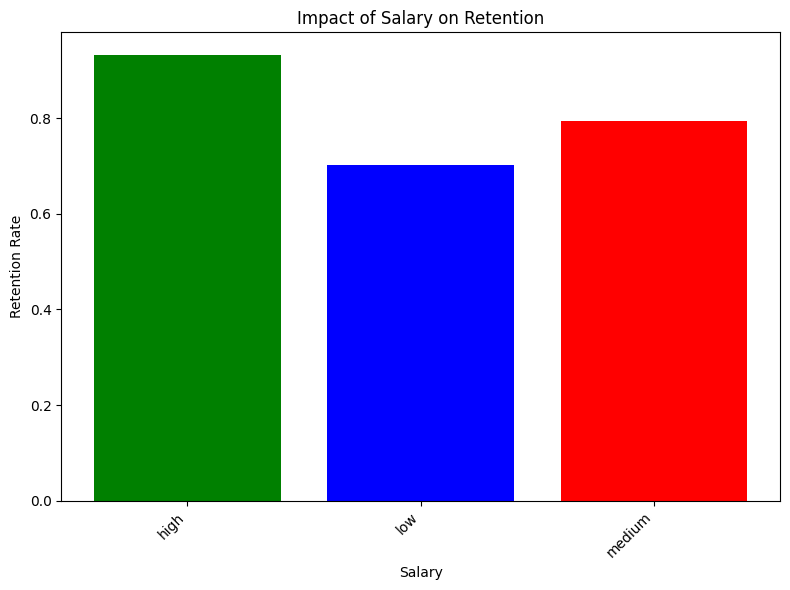

In [ ]:
# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(retention_rate.index, retention_rate['retention_rate'], color=['green', 'blue', 'red'])
plt.xlabel("Salary")
plt.ylabel("Retention Rate")
plt.title("Impact of Salary on Retention")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('HR_comma_sep.csv')  # Assuming your data is in 'HR_comma_sep.csv'

In [ ]:
grouped_data = data.groupby(['Department', 'left'])['satisfaction_level'].count().reset_index()
grouped_data = grouped_data.rename(columns={'satisfaction_level': 'count'})
retention_rate = grouped_data.pivot(index='Department', columns='left', values='count')
retention_rate['retention_rate'] = retention_rate[0] / (retention_rate[0] + retention_rate[1])

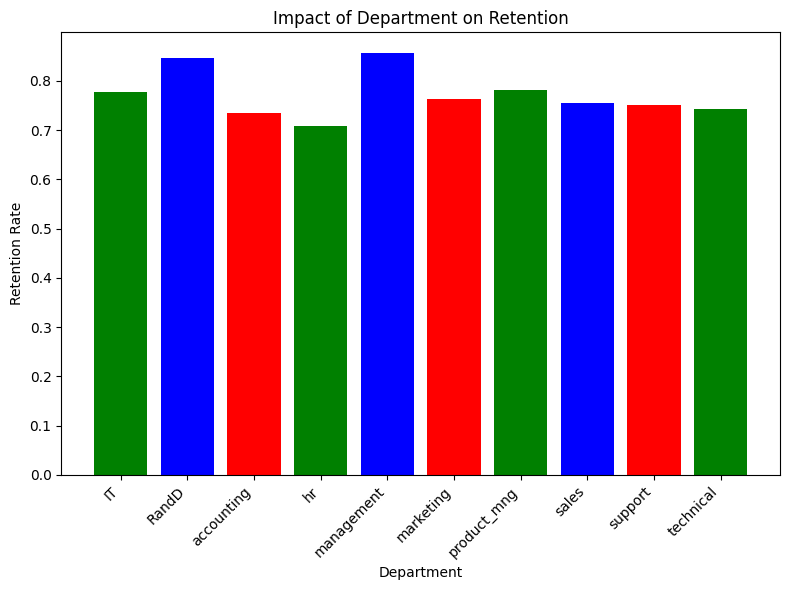

In [ ]:
# Create a bar chart
plt.figure(figsize=(8, 6))
plt.bar(retention_rate.index, retention_rate['retention_rate'], color=['green', 'blue', 'red'])
plt.xlabel("Department")
plt.ylabel("Retention Rate")
plt.title("Impact of Department on Retention")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [ ]:
subdf = df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
subdf.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [ ]:
salary_dummies = pd.get_dummies(subdf.salary, prefix="salary")

In [ ]:
df_with_dummies = pd.concat([subdf,salary_dummies],axis='columns')

In [ ]:
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,low,False,True,False
1,0.80,262,0,medium,False,False,True
2,0.11,272,0,medium,False,False,True
3,0.72,223,0,low,False,True,False
4,0.37,159,0,low,False,True,False


In [ ]:
df_with_dummies.drop('salary',axis='columns',inplace=True)
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [ ]:
X = df_with_dummies
X.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [ ]:
y = df.left

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.3)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
model.score(X_test,y_test)

0.7828571428571428

<ipython-input-12-8b9043a434cd>:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].mean(), inplace=True)     # Fill missing Age with mean


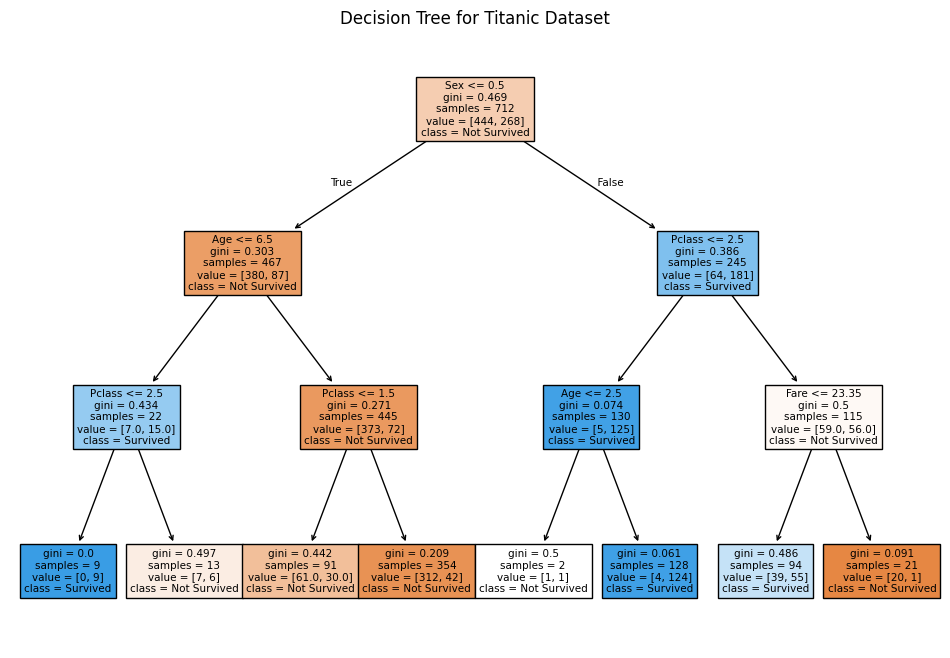

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load Titanic dataset
file_path = "titanic.csv"
data = pd.read_csv("titanic.csv")

# Select features and target
# Assuming columns: 'Pclass', 'Age', 'Sex', 'Fare', 'Survived'
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})  # Convert Sex to numeric
data['Age'].fillna(data['Age'].mean(), inplace=True)     # Fill missing Age with mean

X = data[['Pclass', 'Age', 'Sex', 'Fare']]  # Features
y = data['Survived']                        # Target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Visualize the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=['Pclass', 'Age', 'Sex', 'Fare'], class_names=['Not Survived', 'Survived'], filled=True)
plt.title("Decision Tree for Titanic Dataset")
plt.show()
